## Simulating traffic passing multiple locks on a route
In this notebook, we simulate two individual lock complexes on a network. Two vessels with opposing directions will sail this route, passing both complexes.

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of utils for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable

# package(s) needed for inspecting the output
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev105+gc0ed3023c.d20260415


#### 0. Create environment
We create an environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
We create a directed graph containing five edges:

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('-2',geometry=transform(wgs84eqd_to_wgs84rad,Point(-30000,0)))
graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point( -15000,0)))
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(15000,0)))
graph.add_node('+2',geometry=transform(wgs84eqd_to_wgs84rad,Point(30000,0)))

# add edges
graph.add_edge('-2','-1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-30000, 0),Point(-15000, 0)])), weight=1, length_m=15000)
graph.add_edge('-1','-2', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-15000, 0),Point(-30000, 0)])), weight=1, length_m=15000)

graph.add_edge('-1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-15000, 0),Point(-5000, 0)])), weight=1, length_m=10000)
graph.add_edge('0','-1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(-15000, 0)])), weight=1, length_m=10000)

graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)

graph.add_edge('1','+1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(15000, 0)])), weight=1, length_m=10000)
graph.add_edge('+1','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(15000, 0),Point(5000, 0)])), weight=1, length_m=10000)

graph.add_edge('+2','+1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(15000, 0),Point(30000, 0)])), weight=1, length_m=15000)
graph.add_edge('+1','+2', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(30000, 0),Point(15000, 0)])), weight=1, length_m=15000)

# add graph to environment
env.graph = graph

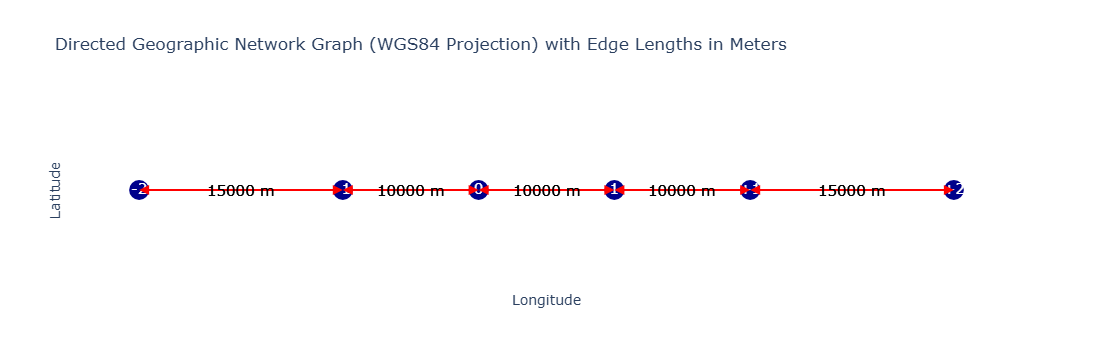

In [4]:
plot_graph(graph)

#### 1+ Adding infrastructure
We will now add two complexes, each with a lock chamber and two waiting areas. We need to construct two lock chambers, and four waiting areas.

In [5]:
lock_chamber_I = IsLockChamber(env=env,
                               lock_depth = 6,
                               name='Lock chamber I',
                               gate_open = '-1',
                               edge = ('-1','0'),
                               geometry_m = Polygon([Point(-10150, -20),Point(-10150, 20),Point(-9850, 20),Point(-9850, -20)]))

lock_chamber_II = IsLockChamber(env=env,
                                lock_depth = 6,
                                name='Lock chamber II',
                                gate_open = '-1',
                                edge = ('1','+1'),
                                geometry_m = Polygon([Point(9850, -20),Point(9850, 20),Point(10150, 20),Point(10150, -20)]))

In [6]:
waiting_area_A_I = IsLockWaitingArea(env=env,
                                     name = 'Waiting area A I',
                                     edge = ('-1','0'),
                                     orientation = 0,
                                     distance_from_edge_start = 0)

waiting_area_B_I = IsLockWaitingArea(env=env,
                                     name = 'Waiting area B I',
                                     edge = ('0','-1'),
                                     orientation = 1,
                                     distance_from_edge_start = 0)

waiting_area_A_II = IsLockWaitingArea(env=env,
                                      name = 'Waiting area A II',
                                      edge = ('1','+1'),
                                      orientation = 0,
                                      distance_from_edge_start = 0)

waiting_area_B_II = IsLockWaitingArea(env=env,
                                      name = 'Waiting area B II',
                                      edge = ('+1','1'),
                                      orientation = 1,
                                      distance_from_edge_start = 0)

In [7]:
lock_complex_I = IsLockComplex(lock_chambers = [lock_chamber_I],
                               waiting_areas = [waiting_area_A_I, waiting_area_B_I],
                               registration_nodes = ['-1','0'],
                               env=env,
                               name = 'Lock complex I',)

lock_complex_II = IsLockComplex(lock_chambers = [lock_chamber_II],
                                waiting_areas = [waiting_area_A_II, waiting_area_B_II],
                                registration_nodes = ['1','+1'],
                                env=env,
                                name = 'Lock complex II',)

#### 2. Create agents
We create two vessels with opposing directions.

In [8]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
    ), 
)

In [9]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [10]:
# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['-2']['geometry'],       # required by Locatable
    "route": nx.dijkstra_path(env.graph, "-2", "+2"),    # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 135,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 17,                                             # required by VesselProperties
    "T": 4,                                             # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['+2']['geometry'],       # required by Locatable
    "route": nx.dijkstra_path(env.graph, "+2", "-2"),    # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 135,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 17,                                             # required by VesselProperties
    "T": 4,                                             # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00')  # required by PassesLockComplex
}  
vessel_2 = Vessel(**data_vessel_2)
vessel_2.name = 'Vessel 2'

#start the simulation
vessels = [vessel_1,vessel_2]
env.process(mission(env, vessel_1));
env.process(mission(env, vessel_2));

#### 3. Run simulation

In [11]:
env.run()

#### 4. Inspect output
##### Logbooks
We can inspect the logbooks of each lock chamber seperately.

In [12]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock_complex_I.lock_chambers['Lock chamber I'].logbook)

print("'{}' logbook data:".format(lock_complex_I.name))  
print('')

display(lock_df)

'Lock complex I' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock gate closing start,2025-01-01 01:26:28.471922,-1,POLYGON ((-0.0911790013381314 -0.0001796630568...
1,Lock gate closing stop,2025-01-01 01:31:28.471922,-1,POLYGON ((-0.0911790013381314 -0.0001796630568...
2,Lock levelling start,2025-01-01 01:31:28.471922,-1,POLYGON ((-0.0911790013381314 -0.0001796630568...
3,Lock levelling stop,2025-01-01 01:41:28.471922,0,POLYGON ((-0.0911790013381314 -0.0001796630568...
4,Lock gate opening start,2025-01-01 01:41:28.471922,0,POLYGON ((-0.0911790013381314 -0.0001796630568...
5,Lock gate opening stop,2025-01-01 01:46:28.471922,0,POLYGON ((-0.0911790013381314 -0.0001796630568...
6,Lock gate closing start,2025-01-01 03:19:45.048596,0,POLYGON ((-0.0911790013381314 -0.0001796630568...
7,Lock gate closing stop,2025-01-01 03:24:45.048596,0,POLYGON ((-0.0911790013381314 -0.0001796630568...
8,Lock levelling start,2025-01-01 03:24:45.048596,0,POLYGON ((-0.0911790013381314 -0.0001796630568...
9,Lock levelling stop,2025-01-01 03:34:45.048596,-1,POLYGON ((-0.0911790013381314 -0.0001796630568...


In [13]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock_complex_II.lock_chambers['Lock chamber II'].logbook)

print("'{}' logbook data:".format(lock_complex_II.name))  
print('')

display(lock_df)

'Lock complex II' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock gate closing start,2025-01-01 01:07:30.000000,1,POLYGON ((0.0884840554857729 -0.00017966305682...
1,Lock gate closing stop,2025-01-01 01:12:30.000000,1,POLYGON ((0.0884840554857729 -0.00017966305682...
2,Lock levelling start,2025-01-01 01:12:30.000000,1,POLYGON ((0.0884840554857729 -0.00017966305682...
3,Lock levelling stop,2025-01-01 01:22:30.000000,+1,POLYGON ((0.0884840554857729 -0.00017966305682...
4,Lock gate opening start,2025-01-01 01:22:30.000000,+1,POLYGON ((0.0884840554857729 -0.00017966305682...
5,Lock gate opening stop,2025-01-01 01:27:30.000000,+1,POLYGON ((0.0884840554857729 -0.00017966305682...
6,Lock gate closing start,2025-01-01 01:32:48.471922,+1,POLYGON ((0.0884840554857729 -0.00017966305682...
7,Lock gate closing stop,2025-01-01 01:37:48.471922,+1,POLYGON ((0.0884840554857729 -0.00017966305682...
8,Lock levelling start,2025-01-01 01:37:48.471922,+1,POLYGON ((0.0884840554857729 -0.00017966305682...
9,Lock levelling stop,2025-01-01 01:47:48.471922,1,POLYGON ((0.0884840554857729 -0.00017966305682...


#### Gantt chart of event table
Combining these logbooks with the ones of the vessels results in a rather interesting Gantt chart.

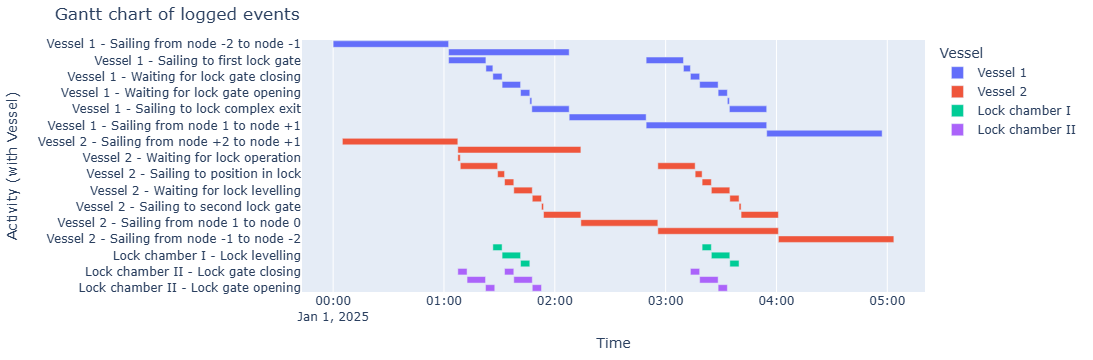

In [14]:
df_eventtable = logbook2eventtable([*vessels, lock_complex_I.lock_chambers['Lock chamber I'], lock_complex_II.lock_chambers['Lock chamber II']])
fig = generate_vessel_gantt_chart(df_eventtable)

#### Time-distance diagram of vessels passing the lock and planning info
We can plot the time-distance diagram for each lock complex. We can add both plots in one figure with a bit of magic, using an offset of half the distance between the lock (+/- 10000 m). Furthermore, we have to ignore the double plotting of the vessels.

Both locks operate separately. Vessel 2 has some extra waiting time, as an empty lock operation was required.

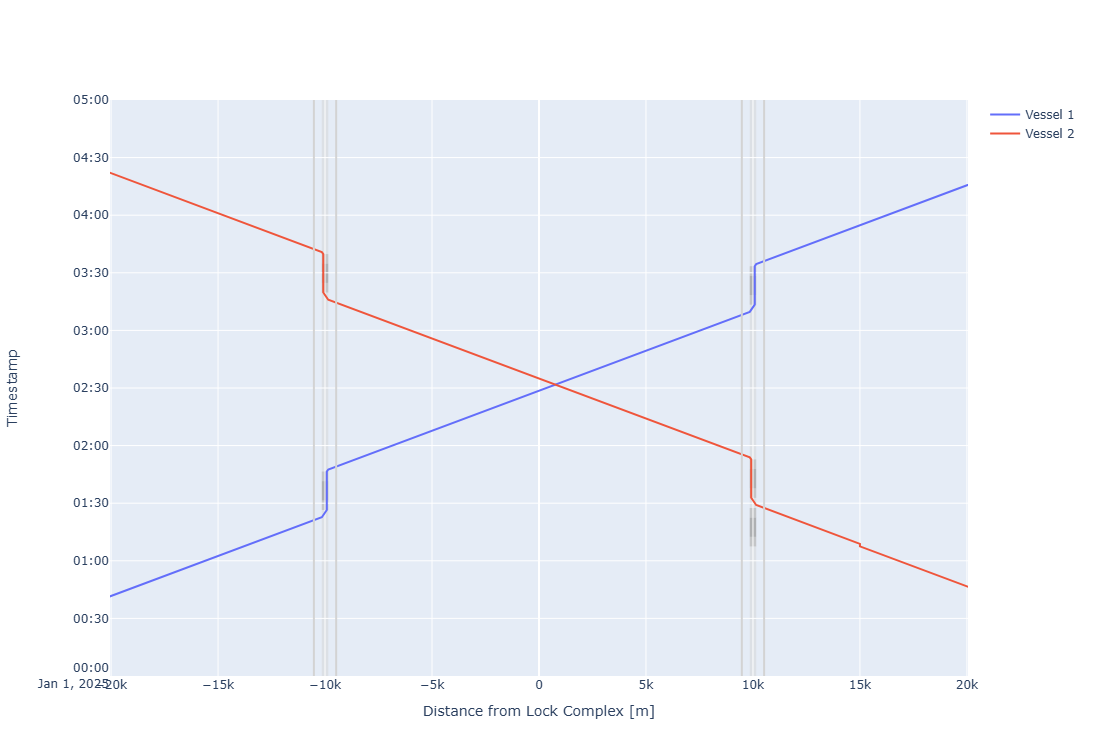

In [15]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

from plotly.subplots import make_subplots
fig = make_subplots()

# We can plot the time-distance diagram
fig = lock_complex_I.lock_chambers['Lock chamber I'].plot(xlimmin = -20050, 
                                                          xlimmax = 20050,
                                                          offset_x = -10000,
                                                          ylimmin = pd.Timestamp('2025-01-01 00:00:00'),
                                                          ylimmax = pd.Timestamp('2025-01-01 05:00:00'),
                                                          method='Plotly',
                                                          boundary_nodes = ['-2','+2'], 
                                                          fig = fig)

# We can plot the time-distance diagram
fig = lock_complex_II.lock_chambers['Lock chamber II'].plot(xlimmin = -20050, 
                                                            xlimmax = 20050,
                                                            offset_x = 10000,
                                                            ylimmin = pd.Timestamp('2025-01-01 00:00:00'),
                                                            ylimmax = pd.Timestamp('2025-01-01 05:00:00'),
                                                            method='Plotly',
                                                            boundary_nodes = ['-2','+2'],
                                                            fig=fig)

fig.data = fig.data[:2]

fig.update_layout(height=cm_to_pixels(20))